In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, auc, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121

2025-04-22 17:27:14.010381: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-22 17:27:14.063158: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-22 17:27:15.255250: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Directory paths
healthy = '/home/rizk_lab/shared/Sony/Seminar/Chest_X-Ray_Dataset_Final/Healthy'
unhealthy = '/home/rizk_lab/shared/Sony/Seminar/Chest_X-Ray_Dataset_Final/UnHealthy'

In [3]:
# image size
image_size = (224, 224)

# Loading images and labels
images = []
labels = []

In [4]:
# Load healthy images
for filename in os.listdir(healthy):
    # Convert filename to string
    filename = str(filename)
    img_path = os.path.join(healthy, filename)
    img = load_img(img_path, target_size=image_size)
    img_array = img_to_array(img)
    images.append(img_array)
    labels.append(0) # Healthy lungs labeled as 0

In [5]:
# Load unhealthy images
for filename in os.listdir(unhealthy):
    # Convert filename to string
    filename = str(filename)
    img_path = os.path.join(unhealthy, filename)
    img = load_img(img_path, target_size=image_size)
    img_array = img_to_array(img)
    images.append(img_array)
    labels.append(1) # unhealthy lungs labeled as 1

In [6]:
# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

In [7]:
# Normalizing images
images = images/255.0

In [8]:
# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [9]:
# CNN architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

/home/usd.local/sonyreddy.gurram/anaconda3/envs/jupyter/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Train the model
epochs = 20
history = model.fit(X_train, y_train, batch_size=32, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.8690 - loss: 0.3310 - val_accuracy: 0.9071 - val_loss: 0.1978
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.9359 - loss: 0.1578 - val_accuracy: 0.9583 - val_loss: 0.1153
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9702 - loss: 0.0962 - val_accuracy: 0.9476 - val_loss: 0.1217
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9732 - loss: 0.0753 - val_accuracy: 0.9714 - val_loss: 0.0876
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.9814 - loss: 0.0559 - val_accuracy: 0.9738 - val_loss: 0.0842
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.9841 - loss: 0.0483 - val_accuracy: 0.9762 - val_loss: 0.0775
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9786 - val_loss: 0.0904
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.9913 - loss: 0

In [11]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9603 - loss: 0.1269
Test accuracy: 0.9714285731315613


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.98       703
   UnHealthy       0.94      0.88      0.91       137

    accuracy                           0.97       840
   macro avg       0.96      0.94      0.95       840
weighted avg       0.97      0.97      0.97       840

Precision: 0.937984496124031
Recall: 0.8832116788321168
F1-score: 0.9097744360902256
Confusion Matrix:
[[695   8]
 [ 16 121]]


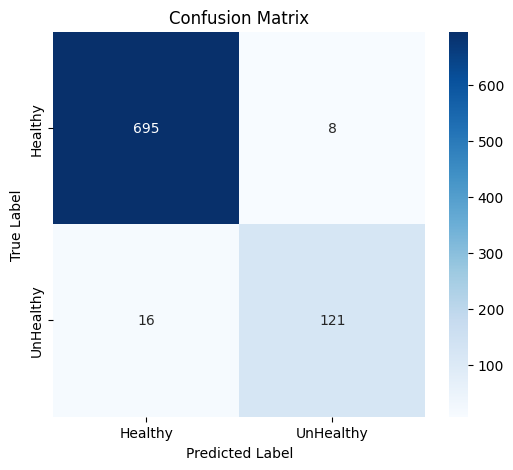

In [24]:
# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'UnHealthy']))

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1}")

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy", "UnHealthy"], yticklabels=["Healthy", "UnHealthy"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

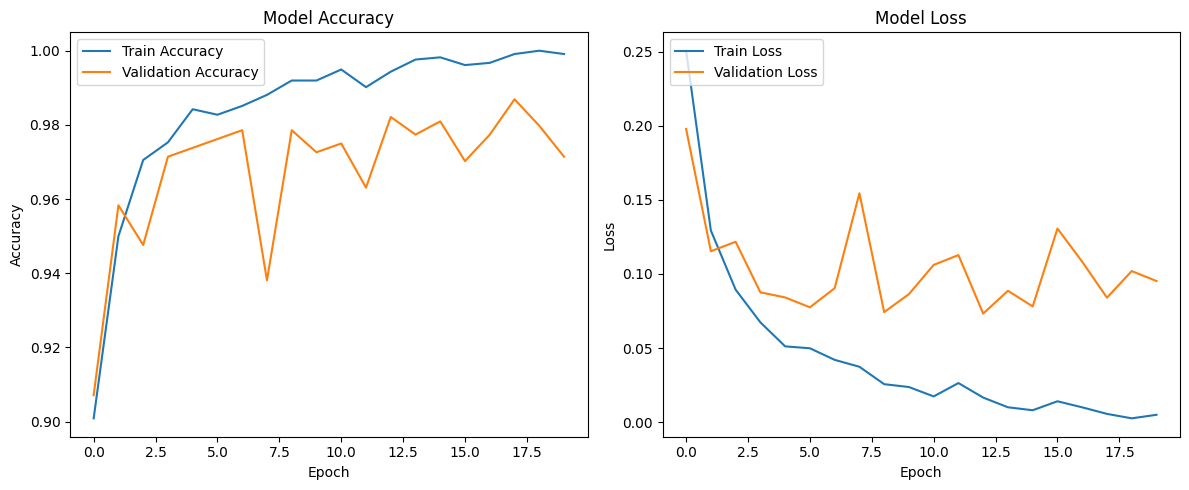

In [13]:
# Plotting accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# Show the plots
plt.tight_layout()
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


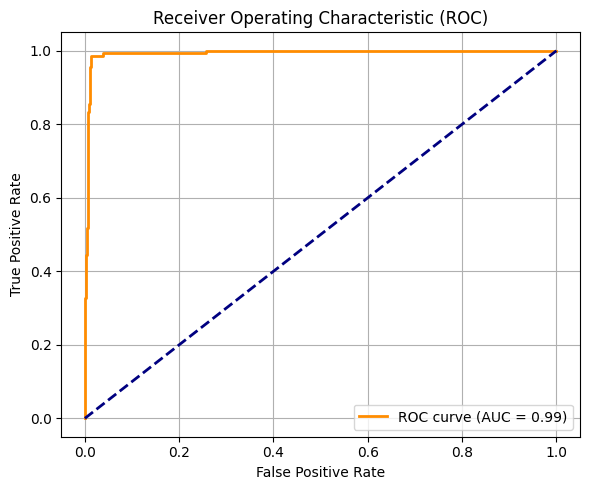

In [14]:
# Get predicted probabilities
y_probs = model.predict(X_test).ravel()  # Use probabilities instead of binary predictions

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Load VGG16 base without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base layers

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=predictions)

# Compile
model_vgg16.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Train
history_vgg = model_vgg16.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), class_weight=class_weight_dict)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 881ms/step - accuracy: 0.4452 - loss: 0.7231 - val_accuracy: 0.9214 - val_loss: 0.5803
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 92s 876ms/step - accuracy: 0.6764 - loss: 0.6292 - val_accuracy: 0.8548 - val_loss: 0.5635
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 868ms/step - accuracy: 0.7629 - loss: 0.5341 - val_accuracy: 0.8964 - val_loss: 0.4750
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 864ms/step - accuracy: 0.8402 - loss: 0.4713 - val_accuracy: 0.9143 - val_loss: 0.4085
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 864ms/step - accuracy: 0.8639 - loss: 0.4405 - val_accuracy: 0.8881 - val_loss: 0.3968
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 871ms/step - accuracy: 0.8939 - loss: 0.3776 - val_accuracy: 0.9024 - val_loss: 0.3496
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 866ms/step - accuracy: 0.8869 - loss: 0.3644 - val_accuracy: 0.9190 - val_loss: 0.3016
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 872ms/step - accuracy: 0.9098 - loss: 0

In [16]:
# Evaluate on test data
test_loss_vgg16, test_acc_vgg16 = model_vgg16.evaluate(X_test, y_test)
print("VGG16 Test Accuracy:", test_acc_vgg16)

# Predict
y_pred_vgg16 = (model_vgg16.predict(X_test) > 0.5).astype(int)

# Report
print("VGG16 Classification Report:")
print(classification_report(y_test, y_pred_vgg16, target_names=['Healthy', 'UnHealthy']))

# Confusion Matrix
print("VGG16 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_vgg16))

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 673ms/step - accuracy: 0.9468 - loss: 0.1759
VGG16 Test Accuracy: 0.9428571462631226
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 677ms/step
VGG16 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.94      0.96       703
   UnHealthy       0.76      0.96      0.85       137

    accuracy                           0.94       840
   macro avg       0.87      0.95      0.91       840
weighted avg       0.95      0.94      0.95       840

VGG16 Confusion Matrix:
[[661  42]
 [  6 131]]


In [17]:
# Load VGG19 base without top layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base layers

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_vgg19 = Model(inputs=base_model.input, outputs=predictions)

# Compile
model_vgg19.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Train
history_vgg19 = model_vgg19.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5888 - loss: 0.7451 - val_accuracy: 0.8655 - val_loss: 0.6005
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.6541 - loss: 0.6370 - val_accuracy: 0.8286 - val_loss: 0.5743
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7564 - loss: 0.5531 - val_accuracy: 0.7583 - val_loss: 0.5816
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7851 - loss: 0.5071 - val_accuracy: 0.8690 - val_loss: 0.4745
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8459 - loss: 0.4652 - val_accuracy: 0.8607 - val_loss: 0.4539
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8603 - loss: 0.4242 - val_accuracy: 0.9048 - val_loss: 0.3912
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8778 - loss: 0.4017 - val_accuracy: 0.9119 - val_loss: 0.3431
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8835 - loss: 0.3849 - val_accu

In [18]:
# Evaluate on test data
test_loss_vgg19, test_acc_vgg19 = model_vgg19.evaluate(X_test, y_test)
print("VGG19 Test Accuracy:", test_acc_vgg19)

# Predict
y_pred_vgg19 = (model_vgg19.predict(X_test) > 0.5).astype(int)

# Report
print("VGG19 Classification Report:")
print(classification_report(y_test, y_pred_vgg19, target_names=['Healthy', 'UnHealthy']))

# Confusion Matrix
print("VGG19 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_vgg19))

27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 841ms/step - accuracy: 0.9469 - loss: 0.1950
VGG19 Test Accuracy: 0.9523809552192688
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 861ms/step
VGG19 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.95      0.97       703
   UnHealthy       0.79      0.96      0.87       137

    accuracy                           0.95       840
   macro avg       0.89      0.96      0.92       840
weighted avg       0.96      0.95      0.95       840

VGG19 Confusion Matrix:
[[668  35]
 [  5 132]]


In [19]:
# Load ResNet50 base without top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base layers

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Compile
model_resnet.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Train
history_resnet = model_resnet.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)


Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 454ms/step - accuracy: 0.4986 - loss: 0.7569 - val_accuracy: 0.8369 - val_loss: 0.6643
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 437ms/step - accuracy: 0.4887 - loss: 0.7242 - val_accuracy: 0.1679 - val_loss: 0.7125
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 45s 434ms/step - accuracy: 0.4557 - loss: 0.7217 - val_accuracy: 0.3274 - val_loss: 0.6988
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 434ms/step - accuracy: 0.5994 - loss: 0.6744 - val_accuracy: 0.1631 - val_loss: 0.7283
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 438ms/step - accuracy: 0.5059 - loss: 0.6850 - val_accuracy: 0.8310 - val_loss: 0.6270
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 45s 433ms/step - accuracy: 0.5872 - loss: 0.6798 - val_accuracy: 0.6988 - val_loss: 0.6875
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 434ms/step - accuracy: 0.5325 - loss: 0.6720 - val_accuracy: 0.1631 - val_loss: 0.7389
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 45s 434ms/step - accuracy: 0.4291 - loss: 0

In [20]:
# Evaluate on test data
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(X_test, y_test)
print("Resnet50 Test Accuracy:", test_acc_resnet)

# Predict
y_pred_resnet = (model_resnet.predict(X_test) > 0.5).astype(int)

# Report
print("Resnet50 Classification Report:")
print(classification_report(y_test, y_pred_resnet, target_names=['Healthy', 'UnHealthy']))

# Confusion Matrix
print("Resnet50 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_resnet))

27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 342ms/step - accuracy: 0.8076 - loss: 0.6121
Resnet50 Test Accuracy: 0.8190476298332214
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step
Resnet50 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.90      0.88      0.89       703
   UnHealthy       0.45      0.50      0.48       137

    accuracy                           0.82       840
   macro avg       0.68      0.69      0.68       840
weighted avg       0.83      0.82      0.82       840

Resnet50 Confusion Matrix:
[[619  84]
 [ 68  69]]


In [21]:
# Load DenseNet121 base without top layers
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base layers

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_densenet = Model(inputs=base_model.input, outputs=predictions)

# Compile
model_densenet.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Train
history_densenet = model_densenet.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)


Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 64s 527ms/step - accuracy: 0.6988 - loss: 0.6935 - val_accuracy: 0.9452 - val_loss: 0.2999
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 509ms/step - accuracy: 0.8836 - loss: 0.3385 - val_accuracy: 0.9619 - val_loss: 0.2153
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 509ms/step - accuracy: 0.9268 - loss: 0.2426 - val_accuracy: 0.9643 - val_loss: 0.1751
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 54s 519ms/step - accuracy: 0.9444 - loss: 0.1902 - val_accuracy: 0.9690 - val_loss: 0.1436
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 55s 528ms/step - accuracy: 0.9536 - loss: 0.1603 - val_accuracy: 0.9762 - val_loss: 0.1088
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 55s 529ms/step - accuracy: 0.9603 - loss: 0.1388 - val_accuracy: 0.9750 - val_loss: 0.1076
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 509ms/step - accuracy: 0.9728 - loss: 0.1070 - val_accuracy: 0.9750 - val_loss: 0.0963
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 502ms/step - accuracy: 0.9638 - loss: 0

In [23]:
# Evaluate on test data
test_loss_densenet, test_acc_densenet = model_densenet.evaluate(X_test, y_test)
print("Densenet Test Accuracy:", test_acc_densenet)

# Predict
y_pred_densenet = (model_densenet.predict(X_test) > 0.5).astype(int)

# Report
print("Densenet Classification Report:")
print(classification_report(y_test, y_pred_densenet, target_names=['Healthy', 'UnHealthy']))

# Confusion Matrix
print("Densenet Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_densenet))

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - accuracy: 0.9815 - loss: 0.0551
Densenet Test Accuracy: 0.9833333492279053
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step
Densenet Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.98      0.99       703
   UnHealthy       0.92      0.99      0.95       137

    accuracy                           0.98       840
   macro avg       0.96      0.98      0.97       840
weighted avg       0.98      0.98      0.98       840

Densenet Confusion Matrix:
[[691  12]
 [  2 135]]
